# Deskriptive Statistiken und Datenvisualisierungen

## Quelle des Datensets

### Das Datenset ist ein öffentlich verfügbares Datenset für Forschungszwecke von Cortez et al. (2009).

Quelle: P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis (2009).   
Modeling wine preferences by data mining from physicochemical properties.  
Decision Support Systems, 47(4), 547–553.   
Link zum Artikel: https://doi.org/10.1016/j.dss.2009.05.016  
Link zum Datenset: https://archive.ics.uci.edu/dataset/186/wine+quality  

### Setup (Libraries)

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Die CSV Dateien einlesen

In [27]:
df_redwine = pd.read_csv("winequality-red.csv", sep=";")
df_whitewine = pd.read_csv("winequality-white.csv", sep=";")

### Erster Überblick über die Spalten und Informationen der Spalten

In [29]:
df_redwine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [31]:
df_whitewine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### Die beiden CSV Dateien für weitere Bearbeitung zu einer zusammenführen

In [40]:
df_redwine['type'] = 'red' # Spalte zur Unterscheidung der Weintypen in der zusammengeführten CSV
df_whitewine['type'] = 'white' # Spalte zur Unterscheidung der Weintypen in der zusammengeführten CSV

red_white_wine = pd.concat([df_redwine, df_whitewine], ignore_index = True) # Zusammenführung
red_white_wine.to_csv("winequality_red_white.csv", sep = ";", index=False) # Neue CSV

### Deskriptive Statistiken, Graphen und Infos zu den Daten

In [50]:
df = pd.read_csv("winequality_red_white.csv", sep=";")

df.info() # Überblick zu Gesamtanzahl der Zeilen, Datentypen

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [95]:
df.describe() # Zeigt Max und Min Werte, Durschnitt etc.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


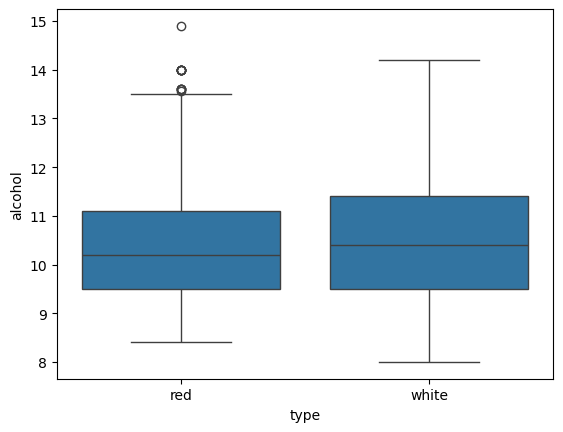

In [99]:
sns.boxplot(x='type', y='alcohol', data = df) # Boxplot, Alkoholgehalt vom Rod- und Weißwei
plt.show()

In [89]:
df.groupby('type')['alcohol'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
red,1599.0,10.422983,1.065668,8.4,9.5,10.2,11.1,14.9
white,4898.0,10.514267,1.230621,8.0,9.5,10.4,11.4,14.2


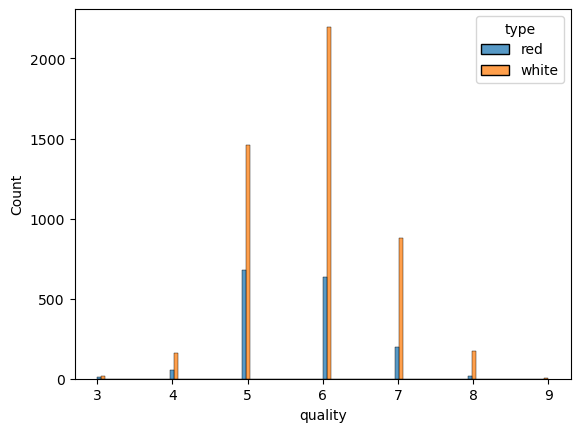

In [97]:
sns.histplot(data=df, x='quality', hue='type', multiple='dodge') # Histogramm, Verteilung der Qualität von Rod- und Weißwein
plt.show()

In [121]:
df.groupby(['quality', 'type']).size().unstack()

type,red,white
quality,,
3,10.0,20.0
4,53.0,163.0
5,681.0,1457.0
6,638.0,2198.0
7,199.0,880.0
8,18.0,175.0
9,NaN,5.0


In [117]:
df.groupby('type')['quality'].mean()

type
red      5.636023
white    5.877909
Name: quality, dtype: float64